In [1]:
!pip install split-folders mtcnn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 43.1 MB/s eta 0:00:00


In [2]:
import os
import shutil
import glob
import gc
import cv2
import random
import splitfolders
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from mtcnn import MTCNN
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.applications import Xception
from tensorflow.keras.callbacks import ModelCheckpoint, CSVLogger
from sklearn.metrics import classification_report, roc_auc_score, accuracy_score, confusion_matrix

2026-06-30 06:08:21.414952: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782799701.784334      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782799701.883492      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782799702.814720      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782799702.814769      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782799702.814771      23 computation_placer.cc:177] computation placer alr

In [3]:
# MTCNN CROPPING & DATA SPLITTING
print("deteksi path dataset")

try:
    FAKE_FILES = glob.glob('/kaggle/input/**/cropped_face/fake/**/*.*', recursive=True)
    REAL_FILES = glob.glob('/kaggle/input/**/cropped_face/real/**/*.*', recursive=True)

    REAL_FILES = [f for f in REAL_FILES if os.path.isfile(f)]
    FAKE_FILES = [f for f in FAKE_FILES if os.path.isfile(f)]
    
    print(f"Total Real : {len(REAL_FILES)} files")
    print(f"Total Fake : {len(FAKE_FILES)} files")
except Exception as e:
    raise FileNotFoundError(f"ERROR: {e}")

detector = MTCNN()
CROPPED_DIR = '/kaggle/working/cropped_dataset'
FINAL_DIR = '/kaggle/working/final_dataset'

os.makedirs(f'{CROPPED_DIR}/real', exist_ok=True)
os.makedirs(f'{CROPPED_DIR}/fake', exist_ok=True)

def process_and_crop(file_list, category, max_files=15000):
    print(f"Memproses kategori {category}")
    saved_count = 0
    
    random.shuffle(file_list) 
    
    for img_path in file_list[:max_files]:
        img = cv2.imread(img_path)
        if img is None: continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        try:
            results = detector.detect_faces(img_rgb)
        except Exception:
            # Jika MTCNN crash karena gambar anomali, lewati gsmbar
            continue
        
        if results:
            x, y, w, h = results[0]['box']
            margin_x, margin_y = int(w * 0.2), int(h * 0.2)
            
            x1, y1 = max(0, x - margin_x), max(0, y - margin_y)
            x2, y2 = min(img.shape[1], x + w + margin_x), min(img.shape[0], y + h + margin_y)
            
            face_crop = img[y1:y2, x1:x2]
            if face_crop.size > 0:
                face_resized = cv2.resize(face_crop, (128, 128))
                safe_name = f"cropped_{hash(img_path)}.jpg"
                cv2.imwrite(os.path.join(CROPPED_DIR, category, safe_name), face_resized)
                saved_count += 1
                
        if saved_count % 1000 == 0 and saved_count > 0:
            print(f"   -> {saved_count} wajah berhasil di-crop...")

process_and_crop(REAL_FILES, 'real', max_files=10000)
process_and_crop(FAKE_FILES, 'fake', max_files=10000)

print("\nMembagi dataset 80:20...")
splitfolders.ratio(CROPPED_DIR, output=FINAL_DIR, seed=42, ratio=(0.8, 0.2))

# Bersihkan storage
shutil.rmtree(CROPPED_DIR)
print("Selesai! dataset siap di-training.")

deteksi path dataset
Total Real : 70000 files
Total Fake : 63569 files


I0000 00:00:1782799943.455772      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Memproses kategori real
   -> 1000 wajah berhasil di-crop...
   -> 2000 wajah berhasil di-crop...
   -> 3000 wajah berhasil di-crop...
   -> 4000 wajah berhasil di-crop...
   -> 5000 wajah berhasil di-crop...
   -> 6000 wajah berhasil di-crop...
   -> 7000 wajah berhasil di-crop...
   -> 8000 wajah berhasil di-crop...
   -> 9000 wajah berhasil di-crop...
Memproses kategori fake
   -> 1000 wajah berhasil di-crop...
   -> 2000 wajah berhasil di-crop...
   -> 3000 wajah berhasil di-crop...
   -> 4000 wajah berhasil di-crop...
   -> 5000 wajah berhasil di-crop...
   -> 5000 wajah berhasil di-crop...
   -> 6000 wajah berhasil di-crop...
   -> 7000 wajah berhasil di-crop...
   -> 8000 wajah berhasil di-crop...
   -> 9000 wajah berhasil di-crop...
   -> 9000 wajah berhasil di-crop...

Membagi dataset 80:20...


Copying files: 19081 files [00:02, 7392.30 files/s]


Selesai! dataset siap di-training.


In [4]:
DATASET_PATH = '/kaggle/working/final_dataset'
IMG_SIZE = 128
BATCH_SIZE = 64 # bisa diturunkan ke 32 kalau RAM GPU Colab penuh
EPOCHS = 10

In [5]:
# 1. FUNGSI DEGRADASI LIVE STREAM SIMULATOR
def degradation_augmentation(image):
    img = image.copy().astype(np.uint8)
    
    # Efek 1: motion / gaussian blur (simulasi orang bergerak saat live) - 30%
    if random.random() < 0.3:
        k = random.choice([3, 5]) # Ukuran blur
        img = cv2.GaussianBlur(img, (k, k), 0)
        
    # Efek 2: Random noise / grain (simulasi kamera hp low-light) - 30%
    if random.random() < 0.3:
        noise = np.random.normal(0, 15, img.shape) # Mean 0, std_dev 15
        img = np.clip(img + noise, 0, 255).astype(np.uint8)
        
    # Efek 3: JPEG compression / piksel pecah - 40%
    if random.random() < 0.4:
        quality = random.randint(30, 60) # Kualitas rendah sampai sedang (0-100)
        encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), quality]
        result, encimg = cv2.imencode('.jpg', img, encode_param)
        if result:
            img = cv2.imdecode(encimg, 1)

    return img.astype(np.float32)

# DATA PREPROCESSING & AUGMENTATION
# Label mapping sesuai request: Real = 0, Fake = 1
CLASS_NAMES = ['real', 'fake']

# Tambahkan argumen `preprocessing_function` di sini
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode='nearest',
    preprocessing_function=degradation_augmentation
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# 3. LOAD GENERATORS
train_generator = train_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'train'),
    target_size=(128, 128),  
    batch_size=32,           
    class_mode='binary',
    classes=CLASS_NAMES,     # mapping Real=0, Fake=1
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    os.path.join(DATASET_PATH, 'val'),
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    classes=CLASS_NAMES,
    shuffle=False
)

Found 15264 images belonging to 2 classes.
Found 3817 images belonging to 2 classes.


In [6]:
os.makedirs('/kaggle/working/log', exist_ok=True)
strategy = tf.distribute.MirroredStrategy()
callbacks = [
    ModelCheckpoint('/kaggle/working/log/xception_model.h5', monitor='val_loss', save_best_only=True, verbose=1),
    CSVLogger('/kaggle/working/log/xception_training_log.csv', append=True)
]

INFO:tensorflow:Using MirroredStrategy with devices ('/job:localhost/replica:0/task:0/device:GPU:0',)


In [7]:
# MODEL XCEPTION
with strategy.scope():
    base_model = Xception(weights='imagenet', include_top=False, input_shape=(128, 128, 3))
    base_model.trainable = True
    for layer in base_model.layers[:50]:
        layer.trainable = False

    model_xception = Sequential([
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.6), 
        Dense(1, activation='sigmoid')
    ])
    model_xception.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00005), loss='binary_crossentropy', metrics=['accuracy'])

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [8]:
model_xception.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 4, 4, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,124,393 (80.58 MB)

 Trainable params: 17,810,881 (67.94 MB)

 Non-trainable params: 3,313,512 (12.64 MB)

In [9]:
history_xception = model_xception.fit(train_generator, epochs=EPOCHS, validation_data=val_generator, callbacks=callbacks)

model_xception.save('/kaggle/working/log/xception_model.h5')

INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
Epoch 1/10


I0000 00:00:1782803256.950220      73 cuda_dnn.cc:529] Loaded cuDNN version 91002


477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - accuracy: 0.7631 - loss: 0.5209INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).
INFO:tensorflow:Reduce to /job:localhost/replica:0/task:0/device:CPU:0 then broadcast to ('/job:localhost/replica:0/task:0/device:CPU:0',).

Epoch 1: val_loss improved from None to 0.11972, saving model to /kaggle/working/log/xception_model.h5



Epoch 1: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 106s 194ms/step - accuracy: 0.8462 - loss: 0.3552 - val_accuracy: 0.9604 - val_loss: 0.1197
Epoch 2/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.9301 - loss: 0.1807
Epoch 2: val_loss improved from 0.11972 to 0.07293, saving model to /kaggle/working/log/xception_model.h5



Epoch 2: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 94s 196ms/step - accuracy: 0.9338 - loss: 0.1682 - val_accuracy: 0.9735 - val_loss: 0.0729
Epoch 3/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step - accuracy: 0.9544 - loss: 0.1222
Epoch 3: val_loss improved from 0.07293 to 0.05711, saving model to /kaggle/working/log/xception_model.h5


...


Epoch 5: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 90s 189ms/step - accuracy: 0.9731 - loss: 0.0765 - val_accuracy: 0.9832 - val_loss: 0.0433
Epoch 6/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step - accuracy: 0.9780 - loss: 0.0631
Epoch 6: val_loss improved from 0.04332 to 0.04086, saving model to /kaggle/working/log/xception_model.h5



Epoch 6: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 91s 190ms/step - accuracy: 0.9777 - loss: 0.0634 - val_accuracy: 0.9851 - val_loss: 0.0409
Epoch 7/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9828 - loss: 0.0525
Epoch 7: val_loss improved from 0.04086 to 0.03220, saving model to /kaggle/working/log/xception_model.h5



Epoch 7: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 89s 187ms/step - accuracy: 0.9819 - loss: 0.0546 - val_accuracy: 0.9869 - val_loss: 0.0322
Epoch 8/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9846 - loss: 0.0477
Epoch 8: val_loss improved from 0.03220 to 0.02941, saving model to /kaggle/working/log/xception_model.h5



Epoch 8: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 90s 188ms/step - accuracy: 0.9841 - loss: 0.0492 - val_accuracy: 0.9895 - val_loss: 0.0294
Epoch 9/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - accuracy: 0.9865 - loss: 0.0383
Epoch 9: val_loss improved from 0.02941 to 0.02626, saving model to /kaggle/working/log/xception_model.h5



Epoch 9: finished saving model to /kaggle/working/log/xception_model.h5
477/477 ━━━━━━━━━━━━━━━━━━━━ 89s 187ms/step - accuracy: 0.9863 - loss: 0.0410 - val_accuracy: 0.9900 - val_loss: 0.0263
Epoch 10/10
477/477 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step - accuracy: 0.9881 - loss: 0.0339
Epoch 10: val_loss did not improve from 0.02626
477/477 ━━━━━━━━━━━━━━━━━━━━ 89s 186ms/step - accuracy: 0.9877 - loss: 0.0368 - val_accuracy: 0.9895 - val_loss: 0.0274


120/120 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step
Accuracy Xception : 0.9895
ROC-AUC Xception  : 0.9996
              precision    recall  f1-score   support

        real       0.99      0.99      0.99      1986
        fake       0.99      0.98      0.99      1831

    accuracy                           0.99      3817
   macro avg       0.99      0.99      0.99      3817
weighted avg       0.99      0.99      0.99      3817



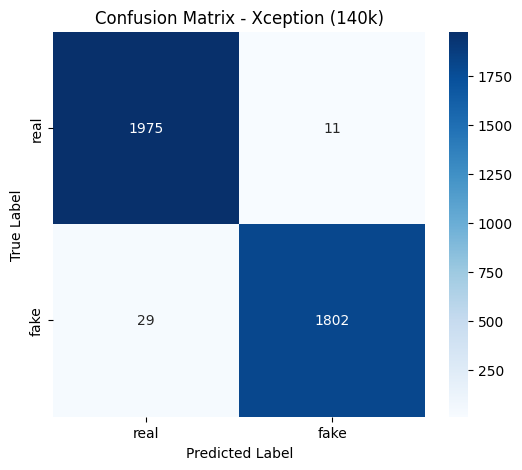

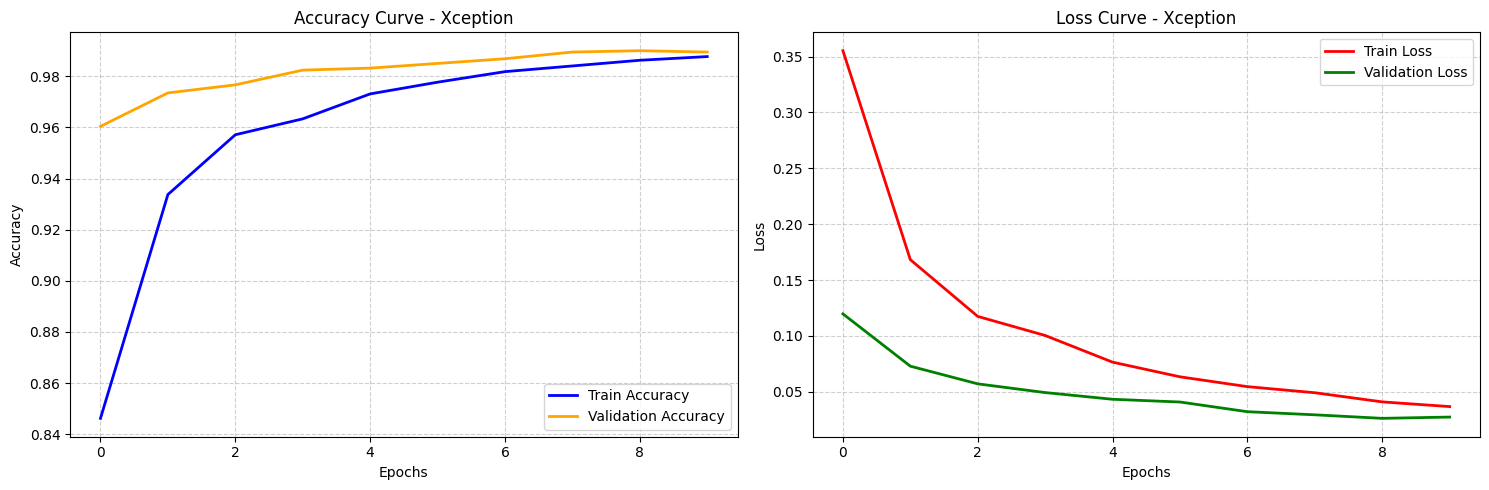

In [10]:
val_generator.reset()
y_true = val_generator.classes
y_pred_probs_xcep = model_xception.predict(val_generator).flatten()
y_pred_xcep = (y_pred_probs_xcep > 0.5).astype(int)

print(f"Accuracy Xception : {accuracy_score(y_true, y_pred_xcep):.4f}")
print(f"ROC-AUC Xception  : {roc_auc_score(y_true, y_pred_probs_xcep):.4f}")
print(classification_report(y_true, y_pred_xcep, target_names=['real', 'fake']))

plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_true, y_pred_xcep)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['real', 'fake'], yticklabels=['real', 'fake'])
plt.title('Confusion Matrix - Xception (140k)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Plot Accuracy & Loss Curves 
plt.figure(figsize=(15, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history_xception.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history_xception.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Accuracy Curve - Xception')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# =Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history_xception.history['loss'], label='Train Loss', color='red', linewidth=2)
plt.plot(history_xception.history['val_loss'], label='Validation Loss', color='green', linewidth=2)
plt.title('Loss Curve - Xception')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()